# Pousser la chansonnette : Classification et stylométrie de paroles de pop

## Introduction <a class="anchor" id="intro"></a>
Le but de ce projet est de réaliser un projet simple et naïf sur le text mining. Je voulais revoir les bases de cette discipline et j'ai trouvé l'occasion de le faire en croisant le très intéressant [git de Hugo Nattagh](https://github.com/Hugo-Nattagh/2017-Hip-Hop) qui présentait son travail ce qui m'a donné envie de faire la même chose. <br><br>

**Dans ce projet, je vais prédire à quel artiste se rapproche le plus le texte d'une chanson.** L'idée étant récréative, j'ai décidé de ne faire cette comparaison que sur 20 des artistes les plus populaires en pop. <br><br>

Pour réaliser ce projet j'ai donc téléchargé un corpus grâce à l'api genius à partir de laquelle j'ai téléchargé les paroles des 20 artistes parmis les plus influents dans la pop. Pour utiliser des algorithmes de machine learning classiques, je suis passé par une vectorisation TF-IDF afin de transformer les mots en une matrice de valeurs numériques. Une fois le corpus vectorisé, j'ai séparé la base de données en 2 : une partie pour l'apprentissage et l'autre pour le test. Le but étant ainsi de créer un modèle ayant des paroles de chanson en entrée et l'artiste vers lequel ces paroles se rapprochent le plus en sortie. Pour cela j'ai entrainé un modèle de classification multinomial naif bayesien avec les données d'apprentissage. Enfin, j'ai fini par évaluer la performance du modèle entrainé avec les données de test.

### Table des matières

* [Introduction](#intro)
* [Création du corpus](#creation_corpus)
    * [Utilisation du Package *lyricsgenius*](#lyricsgenius)
    * [Importation du corpus](#importation_corpus)
    * [Suppression des doublons](#supp_doublons)
    * [Enregistrement du Corpus](#enreg_corpus)
* [Preprocessing](#preprocess)
    * [Restructuration de la base](#restruct_base)
    * [Pipeline de traitement automatique de la base](#trait_base)
    * [Vectorisation](#vectorisation)
* [Modélisation](#modelisation)
    * [Choix du modèle](#choix_modele)
    * [Optimisation des Hyperparamètres](#optimisation_param)
    * [Evaluation du modèle](#eval_modele)
    * [Prédiction](#prediction)
        * ["Hello" de Adele](#adele)
        * ["What a Wonderful World" de Louis Armstrong](#armstrong)
* [Conclusion](#conclusion)
* [Documentation](#documentation)

## Création du corpus <a class="anchor" id="creation_corpus"></a>

### Utilisation du Package *lyricsgenius* <a class="anchor" id="lyricsgenius"></a>

In [1]:
import requests
import lyricsgenius as genius

L'idée ici est d'importer les paroles de chanson de 20 artistes des plus influents afin de créer notre Corpus. Pour cela, on va utiliser une api permettant de nous connecter à Genius et ainsi récupérer les paroles des chansons des artistes qui nous intéresse.

J'ai enregistré mes clés dans un fichier annexe. Vous pouvez créer les votre en cliquant sur ce lien : https://docs.genius.com/. <br>
J'importe donc mes clés afin de me connecter à l'API de Genius. J'ai choisi de le faire avec trois Tokens différents pour parralléliser et accélerer le processus (qui peut être long le cas échéant).

In [2]:
nom_fichier = "genius_id.txt"
dico_token = {}

with open(nom_fichier, "r", encoding="utf-8") as fichier:
    for ligne in fichier:
        cle, valeur = ligne.split(":", 1)
        dico_token[cle.strip()] = valeur.strip()

*Dans un premier temps, essayons donc de comprendre le fonctionnement de l'api en récupérant les 2 chansons les plus populaires de Rihanna...*

In [3]:
#Connection à l'api et création de ma requête.
api=genius.Genius(dico_token["client_token_1"])
artist=api.search_artist('Rihanna', max_songs=2)

#Je ne veux que les métadonnées titres et paroles des chansons.
titles=[song.title for song in artist.songs]
lyrics=[song.lyrics for song in artist.songs]
thingstosave=[]
for i in range(0,len(artist)):
    thingstosave.append((titles[i],lyrics[i]))

In [4]:
thingstosave[0]

('Work',
 '[Chorus: Rihanna]\nWork, work, work, work, work, work\nHe said me haffi work, work, work, work, work, work\nHe see me do mi dirt, dirt, dirt, dirt, dirt, dirt\nAh so me put in work, work, work, work, work, work\nWhen you ah guh learn, learn, learn, learn, learn, learn?\nMe nuh cyar if him hurt, hurt, hurt, hurt, hurting\n\n[Verse 1: Rihanna]\nDry, me ah desert him\nNuh time to have you lurking\nHim ah go act like he nuh like it\nYou know I dealt with you the nicest\nNuh body touch me, you nuh righteous\nNuh badda, text me in a crisis\nI believed all of your dreams, adoration\nYou took my heart and my keys and my patience\nYou took my heart on my sleeve for decoration\nYou mistaken my love I brought for you for foundation\nAll that I wanted from you was to give me\nSomething that I never had\nSomething that you\'ve never seen\nSomething that you\'ve never been, mm\nBut I wake up and act like nothing\'s wrong\n\n[Chorus: Rihanna]\nJust get ready fi work, work, work, work, work

### Importation du corpus <a class="anchor" id="importation_corpus"></a>

Passons maintenant à plus grande échelle ! Nous allons paralléliser par clef d'api. <br>
Je prépare donc en premier lieu la trame pour la méthode pool.map

In [5]:
liste_token = ["client_token_"+ str(i) for i in range(1,4)]

liste_artiste = ["Bruno Mars","Rihanna","Beyonce","Alicia Keys","Frank Ocean",
                 "Amy Winehouse","Justin Timberlake", "Usher", "Mariah Carey", "Justin Bieber","Michael Jackson",
                 "Christina Aguilera", "Chris Brown", "Ne-Yo", "Destiny's Child", "Aaliyah", "Mary J. Blige",
                 "Marvin Gaye", "Janet Jackson", "Stevie Wonder"]

dico_artiste_token = {"client_token_1" : liste_artiste[:7],
                      "client_token_2" : liste_artiste[7:14],
                      "client_token_3" : liste_artiste[14:]}
dico_artiste_token

{'client_token_1': ['Bruno Mars',
  'Rihanna',
  'Beyonce',
  'Alicia Keys',
  'Frank Ocean',
  'Amy Winehouse',
  'Justin Timberlake'],
 'client_token_2': ['Usher',
  'Mariah Carey',
  'Justin Bieber',
  'Michael Jackson',
  'Christina Aguilera',
  'Chris Brown',
  'Ne-Yo'],
 'client_token_3': ["Destiny's Child",
  'Aaliyah',
  'Mary J. Blige',
  'Marvin Gaye',
  'Janet Jackson',
  'Stevie Wonder']}

Je créé ensuite les fonctions que je vais paralleliser.

In [6]:
# Fonction permettant de récupérer n_chansons d'un artiste et de les lister dans un dictionnaire
def telecharger_paroles(api,artiste,n_chansons = 200,download_each_file = False):
    dico_artiste = {}
    artiste_info=api.search_artist(artiste, max_songs=n_chansons)
    dico_artiste = {song.title : song.lyrics for song in artiste_info.songs}
    if download_each_file :
        nom_fichier = artiste.replace(" ","_").replace(",","").replace("&","").replace("-"," ") + ".txt"
        with open(nom_fichier, 'w') as outfile:
            json.dump(dico_artiste, outfile)
    return dico_artiste

# Fonction qui va être paralléliser et permettant de se connecter à l'api Genius afin de créer un dictionnaire par artiste.
data_json = {}
def connect_api(Token,artistes, n_chansons = 200):
    str_token = dico_token[Token]
    api=genius.Genius(str_token,timeout=20, retries=5)
    for artiste in artistes[Token]:
        dico_artiste = telecharger_paroles(api,artiste, n_chansons = n_chansons)
        data_json[artiste] = dico_artiste

Et je lance le programme...<br><b> /!\ cette cellule prend du temps /!\ </b>

In [7]:
from concurrent.futures import ThreadPoolExecutor
import json

with ThreadPoolExecutor(3) as pool:
  values = pool.map(lambda x : connect_api(x,dico_artiste_token),liste_token)

with open("data_json.json", 'w') as outfile:
    json.dump(data_json, outfile)

### Suppression des doublons <a class="anchor" id="supp_doublons"></a>

Il y a parfois des chansons qui sont en doublons étant donné qu'il y a souvent des remix, des edits de radio, ... On va donc faire en sorte qu'il n'y ait qu'une occurence de chaque chanson. <br> J'aurais pu intégrer cette étape lors de la connection à l'api, mais comme je m'en suis rendu compte après le téléchargement du corpus, autant ne pas relancer la boucle et travailler avec ce que j'avais.

In [8]:
import collections
import re
from IPython.display import HTML, display

def supp_doublons_chansons(dico, artiste):
    titres_bruts = list(dico[artiste].keys())
    
    # On créé la Regex pour identifier la partie "variante" à nettoyer
    pattern_nettoyage = re.compile(
        r"\s*(?:[-([][^([)]*(?:remix|edit|live|acoustic|version|radio|mix|ft\.|feat\.)[^([)]*[-)\]]?)",
        flags=re.IGNORECASE,
    )
    
    # On regroupe tous les titres originaux par leur nom "propre"
    groupes_titres = collections.defaultdict(list)
    for titre_original in titres_bruts:
        titre_propre = pattern_nettoyage.sub("", titre_original).strip().lower()
        groupes_titres[titre_propre].append(titre_original)
    
    # Pour chaque groupe, on choisit le MEILLEUR exemplaire original
    # Comme on veut la version épurée, on part du principe que ca sera toujours la version la plus courte
    titres_finaux_conserves = []
    
    for titre_propre, liste_originaux in groupes_titres.items():
        titre_court = min(liste_originaux, key=len, default="")
        titres_finaux_conserves.append(titre_court)
        
    # On affiche les titres écartés
    titres_ecartes = sorted(set(titres_bruts).difference(set(titres_finaux_conserves)))

    if titres_ecartes:
        contenu_html = f"<p>Les chansons de l'artiste <b>{artiste}</b> qui ont été supprimées sont les suivantes :</p>"
        contenu_html += """<details>
        <summary>Afficher la liste des titres supprimés</summary>
        <ul>"""
        for element in titres_ecartes:
            contenu_html += f"<li>{element}</li>"
        contenu_html += "</ul></details>"
    else:
        contenu_html = f"<p>Aucune chanson écartée pour l'artiste {artiste}.</p>"
    display(HTML(contenu_html))

    dico_artiste_sans_doublons = {chanson:paroles for chanson, paroles in dico[artiste].items() if chanson in titres_finaux_conserves}
    return dico_artiste_sans_doublons

In [9]:
corpus = {}
for artiste in data_json:
    dico_artiste_sans_doublons = supp_doublons_chansons(data_json,artiste)
    corpus[artiste] = dico_artiste_sans_doublons

J'ai dorénavant un fichier json avec la structure que je souhaite **sans doublon** que je peux utiliser sans repasser par l'api à chaque fois. Je l'exporte donc au format json.<br>La base de données brute est maintenant prête à être utilisée, je vais la traiter avant de créer mon modèle.

### Enregistrement du Corpus <a class="anchor" id="enreg_corpus"></a>

In [10]:
with open("corpus.json", 'w') as outfile:
    json.dump(corpus, outfile)

## Preprocessing <a class="anchor" id="preprocess"></a>

In [11]:
import json
from unidecode import unidecode

import nltk
from nltk.stem import PorterStemmer
from nltk.stem import WordNetLemmatizer

wnl = WordNetLemmatizer()
stm = PorterStemmer()
with open("corpus.json",encoding="utf-8") as f:
    corpus = json.load(f)
    
import re
import string

corpus ={cle:val for cle, val in corpus.items()}

### Restructuration de la base <a class="anchor" id="restruct_base"></a>

On commence par décomposer notre base pour avoir un vecteur réponse (Y) et une matrice (X) qu'on transformera a terme en matrice TF-IDF :

In [12]:
# Extraction et aplatissement des Titres (title_song_tool), des Données (X) et des Artistes (Y)
X = []
titres_bruts = []
Y = []

for artiste, chansons in corpus.items():
    for titre, paroles in chansons.items():
        titres_bruts.append(titre)
        X.append(paroles)
        Y.append(artiste)

title_song_tool = {i: titre for i, titre in enumerate(titres_bruts)}

print(len(title_song_tool),"chansons importées")

3193 chansons importées


In [13]:
import re
pattern_variante = re.compile(
    r"\s*(?:[-([][^([)]*(?:remix|edit|live|acoustic|version|radio|mix|ft\.|feat\.)[^([)]*[-)\]]?)",
    flags=re.IGNORECASE)

titres_variants_trouves = [titre for titre in title_song_tool.values() if re.search(pattern_variante, titre)]
compteur_variantes = len(titres_variants_trouves)

# On affiche les résultats
print(f"Nombre de chansons variantes : {compteur_variantes}")
contenu_html = """<details>
<summary>Afficher la liste des chansons variantes détectées</summary>
<ul>"""
for titre in titres_variants_trouves:
    contenu_html += f"<li>{titre}</li>"
contenu_html +="</ul></details>"
display(HTML(contenu_html))

Nombre de chansons variantes : 87


On se rend compte qu'il reste des chansons avec des titres alternatifs au titre original dans la base de données. En vérifiant de mon côté j'ai remarqué que la **plupart** des ces variantes étaient restées car le titre original n'était pas parmis les chansons importées. C'est la raison pour laquelle j'ai décidé de toutes les laisser dans le corpus.

### Pipeline de traitement automatique de la base <a class="anchor" id="trait_base"></a>

Il s'agit maintenant de nettoyer notre corpus qui constituera notre base de données. Le but est donc de le standardiser pour capter le plus de variations possibles des termes utilisés dans les chansons. Pour cela on supprime la ponctuation, les majuscules, les espaces inutiles. <br>
Je choisi également de supprimer les chansons dont les paroles font moins de 20 mots.

In [14]:
def cleaner(chanson):
    # On passe en minuscules, on vire les accents et on remplace l'apostrophe courbe ’ de Genius par une apostrophe droite '
    chanson = unidecode(chanson).lower()
    chanson = chanson.replace("’", "'")

    # Nettoyage des bruits spécifiques de Genius (Balises et boutons de partage)
    chanson = re.sub(r"\[.*?\]", " ", chanson)
    chanson = re.sub(r"\d*\s*embed\s*share.*", " ", chanson)
    chanson = re.sub(r"embed\s*copy", " ", chanson)

    # Normalisation des contractions anglaises courantes
    chanson = re.sub(r"n't\b", " not", chanson)
    chanson = re.sub(r"\bi'm\b", "i am", chanson)
    chanson = re.sub(r"'s\b", " is", chanson)
    chanson = re.sub(r"'ll\b", " will", chanson)
    chanson = re.sub(r"'ve\b", " have", chanson)
    chanson = re.sub(r"'re\b", " are", chanson)
    chanson = re.sub(r"'d\b", " would", chanson)

    # On supprime la ponctuation
    ponctuations = string.punctuation + "\n\r"
    chanson = re.sub(f"[{re.escape(ponctuations)}]", " ", chanson)

    # Nettoyage final des espaces multiples
    chanson = re.sub(r"\s+", " ", chanson)

    return chanson.strip()

values = map(cleaner,X)
values = list(values)

who_do_we_remove = {idx:(Y[idx],title_song_tool[idx]) for idx,valeur in enumerate(values) if len(valeur) <= 20}
print(f"{len(who_do_we_remove)} chansons ont été supprimées car il y a moins de 20 mots dans leur texte.")

30 chansons ont été supprimées car il y a moins de 20 mots dans leur texte.


In [15]:
print("la liste des chansons qui ont été supprimées est la suivante :")
for i in who_do_we_remove.keys():
    print(i,":",title_song_tool[i])

la liste des chansons qui ont été supprimées est la suivante :
130 : So Emotional
138 : S.Y.T (Sweet, Young & Tender)
141 : Intro/Overture
142 : Soldier (Dance Interlude)
145 : Life
407 : Don’t Call Me No More
429 : Back & Forth (Ms. Mello Instrumental)
1418 : Main Theme From Trouble Man (2)
1434 : “T” Plays It Cool
1441 : I Want You (Intro Jam)
1444 : T’' Stands For Trouble
1940 : Interlude: Online
1959 : Are You Still Up
1967 : Sweet Dreams
1978 : Back
1981 : Interlude: Come Back
2158 : Kimono Girl
2321 : As I Am (Intro)
2325 : De Novo Adagio
2348 : KEYS
2619 : In Here Somewhere
2625 : White
2626 : Rushes To
2636 : Florida
2995 : Over You
3016 : New Love
3152 : Fresh Leaves
3177 : People Everyday
3185 : She Likes The Rain
3188 : As Dreamers Do


In [16]:
Y  = [artist for i,artist in  enumerate(Y) if i not in who_do_we_remove.keys()]
X  = [lyrics for i,lyrics in  enumerate(values) if i not in who_do_we_remove.keys()]

title_song_tool = {cle:valeur for cle, valeur in title_song_tool.items() if cle not in list(who_do_we_remove.keys())}
## On vérifie que ca a bien supprimé
print(len(title_song_tool))

3163


On passe à la racinisation des mots pour capter le plus de variations possibles du même mot. On en profite pour supprimer les mots vides car ils n'apportent aucune information au document.

In [17]:
from nltk.stem import PorterStemmer
from nltk.corpus import stopwords
english_stopwords = set(stopwords.words("english"))

def stem_stopwords(chanson,liste_motvides):
    return(
        [stm.stem(mot) for mot in chanson.split() if mot not in liste_motvides]
    )

X = [stem_stopwords(chanson,english_stopwords) for chanson in X]

### Vectorisation <a class="anchor" id="vectorisation"></a>

On passe ensuite à la vectorisation. On garde les n-gram de taille 1 et 2 qui sont parfois des informations pertinentes. Les refrains répétant certains mots des dizaines de fois dans les chansons, j'ai fais le choix d'appliquer une échelle logarithmique afin de réduire cet effet parasite (sublinear_tf=True). Les bigrammes vont également créer énormément de bruit car la majorité d'entre eux ne sont présents que dans un seul titre. Je n'ai donc conservé que les unigrammes et bigrammes présents dans au moins deux documents du corpus.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

def dummy_fun(doc):
    return doc

vectorizer = TfidfVectorizer(ngram_range=(1, 2),
                             use_idf=True, smooth_idf=True, # idf lissé
                             min_df=2,
                             sublinear_tf=True,
                             norm='l2',
                             analyzer = 'word',
                             tokenizer=dummy_fun,
                             preprocessor = dummy_fun)

In [19]:
dtm = vectorizer.fit_transform(X)

C:\Users\User\anaconda3\envs\projet_musique\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


On visualise la matrice TF-IdF qu'on obtient :

In [20]:
import pandas as pd
pd.DataFrame(dtm.toarray(),columns=vectorizer.get_feature_names_out())

,0,000,01,01 know,1,1 1,1 2,10,10 9,10 minut,...,zone caus,zone got,zone move,zoom,zoom zoom,zoomin,zz,zz bee,zz come,zz zz
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3158,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3159,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3160,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3161,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Modélisation <a class="anchor" id="modelisation"></a>

### Choix du modèle <a class="anchor" id="choix_modele"></a>

Maintenant que notre matrice TF-IDF est terminée, on passe à la partie prédiction. Le but de ce projet n'étant pas d'être le plus précis possible mais de se réapproprier les différentes techniques de text-mining, j'ai fait le choix de partir sur un modèle de prédiction simple : un modèle de classification multinomial naif bayesien. Il n'a pas beaucoup de paramètres, est rapide d'execution tout en étant capable de gérer le fléau de dimension. C'est d'ailleurs généralement le modèle de référence en classification de texte, notamment en classification multinomial.<br>
J'ai décidé de conserver 67% des observations pour l'apprentissage du modèle et 33% pour le tester et m'assurer de ne pas faire de sur-apprentissage. J'ai réalisé une validation croisée pour le choix des hyperparamètres.

In [21]:
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.naive_bayes import MultinomialNB

x_train,x_test,y_train,y_test = train_test_split(dtm,Y,test_size = 0.33)

In [22]:
MultinomialNB().get_params()

{'alpha': 1.0, 'class_prior': None, 'fit_prior': True, 'force_alpha': True}

### Optimisation des Hyperparamètres <a class="anchor" id="optimisation_param"></a>

Le critère de performance que j'ai décidé d'utiliser pour le choix de mes paramètres est la métrique ROC AUC OVR Weighted. C'est une métrique classique, robuste et spécialement conçu pour les problèmes de classification multiclasse, parfaitement adaptée à ma problématique actuelle. Cette métrique a été utilisée pour le choix des hypermaramètres dans une validation croisée.

In [23]:
import numpy as np

mod= MultinomialNB()

parametres = {
    "alpha": [0.001,0.005,0.01,0.05,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0],
    "fit_prior" : [True, False],

}
grid = GridSearchCV(mod,parametres,verbose=1,scoring = "roc_auc_ovr_weighted",n_jobs=4)
grid.fit(x_train,y_train)

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",MultinomialNB()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.005, ...], 'fit_prior': [True, False]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc_ovr_weighted'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",4
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;-

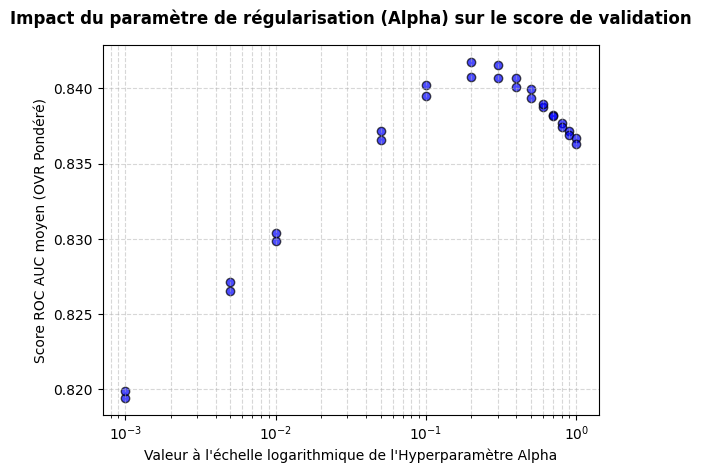

In [24]:
import matplotlib.pyplot as plt

plt.scatter(y= grid.cv_results_["mean_test_score"],
            x = grid.cv_results_["param_alpha"].data,
            color="blue",
            edgecolor="k",
            alpha=0.7)
plt.title(
    "Impact du paramètre de régularisation (Alpha) sur le score de validation",
    fontsize=12,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Valeur à l'échelle logarithmique de l'Hyperparamètre Alpha", fontsize=10)
plt.ylabel("Score ROC AUC moyen (OVR Pondéré)", fontsize=10)

plt.xscale("log")

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.show()

On affiche les meilleurs paramètres :

In [25]:
grid.best_params_

{'alpha': 0.2, 'fit_prior': False}

### Evaluation du modèle <a class="anchor" id="eval_modele"></a>

Et on affiche les résultats de prédiction des meilleurs paramètres

In [26]:
prediction = grid.predict(x_test)

In [27]:
from sklearn.metrics import classification_report, roc_auc_score
roc_auc_weighted = roc_auc_score(
    y_test,
    grid.predict_proba(x_test),
    multi_class="ovr",
    average="weighted",
)

print(classification_report(y_test, prediction))
print("Nombre d'erreur de prédictions sur un total de %d observations : %d, ce qui représente %.3f de précision." % (x_test.shape[0], (y_test != prediction).sum(),(1-(y_test != prediction).sum()/x_test.shape[0])))
print(f"Le Score ROC AUC moyen (OVR Pondéré) est de : {roc_auc_weighted:.3f}")

                    precision    recall  f1-score   support

           Aaliyah       1.00      0.38      0.55        37
       Alicia Keys       0.81      0.21      0.34        61
     Amy Winehouse       0.94      0.33      0.48        49
           Beyonce       0.50      0.09      0.16        64
        Bruno Mars       1.00      0.11      0.20        37
       Chris Brown       0.17      0.88      0.28        56
Christina Aguilera       0.58      0.26      0.36        68
   Destiny's Child       0.77      0.17      0.28        58
       Frank Ocean       0.62      0.30      0.41        66
     Janet Jackson       0.52      0.26      0.35        53
     Justin Bieber       0.21      0.27      0.23        60
 Justin Timberlake       0.56      0.10      0.18        48
      Mariah Carey       0.24      0.38      0.30        55
       Marvin Gaye       0.41      0.92      0.57        53
     Mary J. Blige       0.24      0.50      0.33        58
   Michael Jackson       0.63      0.54

### Prédiction <a class="anchor" id="prediction"></a>

Regardons maintenant vers quel artiste se rapproche des titres iconiques de la musique.

#### "Hello" de Adele <a class="anchor" id="adele"></a>

In [28]:
lyrics = """Hello, it's me I was wondering if after all these years you'd like to meet To go over everything 
They say that time's supposed to heal ya But I ain't done much healing 
Hello, can you hear me? I'm in California dreaming about who we used to be
When we were younger and free 
I've forgotten how it felt before the world fell at our feet
There's such a difference between us
And a million miles
Hello from the other side
I must've called a thousand times
To tell you I'm sorry for everything that I've done
But when I call, you never seem to be home
Hello from the outside
At least I can say that I've tried
To tell you I'm sorry for breaking your heart
But it don't matter, it clearly doesn't tear you apart anymore
Hello, how are you?
It's so typical of me to talk about myself, I'm sorry
I hope that you're well
Did you ever make it out of that town where nothing ever happened?
It's no secret that the both of us are running out of time
So hello from the other side (Other side)
I must've called a thousand times (Thousand times)
To tell you I'm sorry for everything that I've done
But when I call, you never seem to be home
Hello from the outside (Outside)
At least I can say that I've tried (I've tried)
To tell you I'm sorry for breaking your heart
But it don't matter, it clearly doesn't tear you apart anymore
Ooh-ooh, anymore
Ooh-ooh-ooh, anymore
Ooh-ooh, anymore
Anymore
Hello from the other side (Other side)
I must've called a thousand times (Thousand times)
To tell you I'm sorry for everything that I've done
But when I call, you never seem to be home
Hello from the outside (Outside)
At least I can say that I've tried (I've tried)
To tell you I'm sorry for breaking your heart
But it don't matter, it clearly doesn't tear you apart anymore"""

lyrics = cleaner(lyrics)
lyrics = stem_stopwords(lyrics,english_stopwords)

lyrics_dtm = vectorizer.transform(lyrics)
who_does_adele_sound_like = grid.predict_proba(lyrics_dtm)
pd.DataFrame({"artiste":grid.classes_,"probabilité":who_does_adele_sound_like[0]}).sort_values(by = "probabilité",ascending = False).head()

,artiste,probabilité
3,Beyonce,0.118202
18,Usher,0.100323
11,Justin Timberlake,0.082943
0,Aaliyah,0.082004
5,Chris Brown,0.075223


#### "What a Wonderful World" de Louis Armstrong <a class="anchor" id="armstrong"></a>

In [29]:
lyrics = """
I see trees of green, red roses too
I see them bloom for me and you
And I think to myself what a wonderful world.
I see skies of blue and clouds of white
The bright blessed day, the dark sacred night
And I think to myself what a wonderful world.
The colors of the rainbow so pretty in the sky
Are also on the faces of people going by
I see friends shaking hands saying how do you do
They're really saying I love you.
I hear babies crying, I watch them grow
They'll learn much more than I'll never know
And I think to myself what a wonderful world
Yes I think to myself what a wonderful world.
"""

lyrics = cleaner(lyrics)
lyrics = stem_stopwords(lyrics,english_stopwords)

lyrics_dtm = vectorizer.transform(lyrics)
who_does_adele_sound_like = grid.predict_proba(lyrics_dtm)
pd.DataFrame({"artiste":grid.classes_,"probabilité":who_does_adele_sound_like[0]}).sort_values(by = "probabilité",ascending = False).head(5)

,artiste,probabilité
10,Justin Bieber,0.090341
15,Michael Jackson,0.080668
3,Beyonce,0.076520
4,Bruno Mars,0.064778
5,Chris Brown,0.062814


## Conclusion <a class="anchor" id="conclusion"></a>

Ce projet était un moyen ludique pour moi de me remémorer ce qui se faisait en NLP et les étapes dites "classiques" de text mining. J'ai pu revoir les différents procédés pouvant mener à des modèles prédictifs à partir de données textuelles.<br><br>
J'ai identifié de nombreux points que j'aurais pu développer pour répondre de façon plus pertinente à la question de départ. La pop étant un style musical plutôt large, j'aurai pu par exemple me restreindre à un style moins vaste comme le neo-soul ou plus riche en terme de texte comme le rap. J'aurai également pu passer par le procédé de lemmatisation plutôt que celui de racinisation. Une autre autre piste aurait été de télécharger la discographie complète de chacun des artistes et d'utiliser des modèles de prédiction plus complexes comme des llm qui sont connus pour être très performants sur des données textuelles (mais beaucoup plus contraignant d'un point de vue énergétique).<br><br>
Quoiqu'il en soit, ce projet a été un plaisir pour moi de retravailler sur ce type de données et j'espère à l'avenir refaire des projets dans ce domaine, qui plus est dans le domaine de la musique. Encore merci à Hugo Nattagh pour l'idée du projet !

## Documentation <a class="anchor" id="documentation"></a>
*  https://stackoverflow.com/questions/24873773/web-scraping-rap-lyrics-on-rap-genius-w-python
*  https://docs.genius.com/
  
Une idée préliminaire est de s'inspirer du travail de Hugo Nattagh : https://github.com/Hugo-Nattagh/2017-Hip-Hop 